# 3D Soma Segmentation (drop processes)

Segments neuron **cell bodies (soma)** in 3D from single-channel (488/GFP) Imaris `.ims` Z-stacks, discarding thin neurites/processes.

**Approach (classical morphology, no training needed):**
1. Smooth + threshold to get a binary "neuron signal" mask (soma + processes).
2. Strip processes with an anisotropic 3D morphological **opening** (physically-round ellipsoidal structuring element sized between process radius and soma radius) — thin processes are fully eroded away, somas survive.
3. Split any touching somas with a marker-controlled **watershed** on the distance transform, restricted to the opened mask (so processes can't re-enter).
4. Filter surviving objects by volume/solidity to drop debris.
5. Visualize, tabulate stats, save labeled volume.

Uses the same `tiffprocessing` env as `IMS to TIFF conversion.ipynb` (h5py, scipy, scikit-image already installed).

In [2]:
import h5py
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage.filters import gaussian, threshold_triangle
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops_table
from skimage.color import label2rgb

## Parameters

Everything that depends on your optics/biology lives here — tune these first, the rest of the notebook shouldn't need edits.

In [23]:
# --- File ---
ims_path = r"G:\data\GFP\PS8292.ims"
channel = 0  # single 488 channel
resolution_level = 0  # 0 = full resolution

# --- Voxel size (um), from get_voxel_size() in "IMS to TIFF conversion.ipynb" ---
# Confirm per-file if your acquisitions aren't all identical.
voxel_size_zyx = (0.95, 0.1005, 0.1005)  # (Z, Y, X), um/voxel

# --- Expected object sizes (um) ---
# Starting estimates for C. elegans neuron soma vs. neurite processes.
# Inspect a max-intensity projection after running the loader cell below and adjust.
soma_radius_um = 4.0      # ~4 um soma diameter
process_radius_um = 0.25  # ~0.5 um process diameter (near-diffraction-limited)

# Opening radius must satisfy process_radius_um < opening_radius_um < soma_radius_um
# so erosion fully removes processes but leaves a surviving core in each soma.
opening_radius_um = (process_radius_um + soma_radius_um) / 2

# --- Watershed peak separation ---
# Minimum physical distance between two soma centers; prevents over-splitting a single soma.
min_peak_separation_um = soma_radius_um

# --- Denoising ---
# Mild smoothing before thresholding; sigma in physical um, converted to per-axis voxel sigma below.
smoothing_sigma_um = 0.15

# --- Size/shape filter (drops debris or leftover fused blobs) ---
min_soma_volume_um3 = (4 / 3) * np.pi * (soma_radius_um * 0.8) ** 3   # ~1/8 of expected soma volume
max_soma_volume_um3 = (4 / 3) * np.pi * (soma_radius_um * 2.0) ** 3   # ~8x expected soma volume
min_solidity = 0.8  # rejects irregular/branchy leftovers, not a strict roundness test —
# coarse Z sampling relative to soma size (only ~soma_diameter/voxel_size_zyx[0] slices per
# soma) makes even a clean sphere's poles look blocky, which already pulls solidity down

# --- Intensity filter ---
# Volume/solidity alone can't tell a real GFP+ soma apart from soma-sized, soma-shaped debris
# (e.g. autofluorescent granules) — that needs brightness. Expressed as a multiple of THIS
# image's own threshold so it stays meaningful across files with different overall brightness.
min_mean_intensity_factor = 1.3

## Load the volume

Volume shape (Z, Y, X): (40, 2048, 2048), dtype: uint16


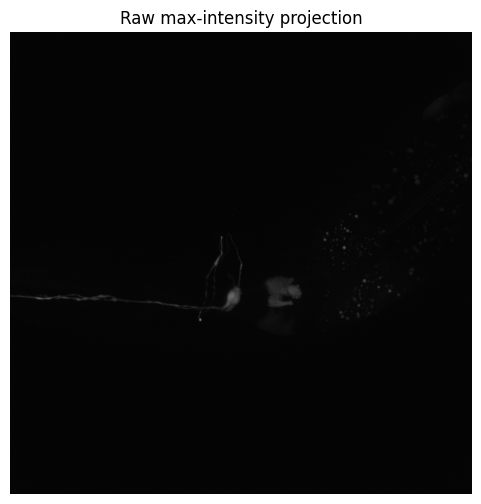

In [5]:
def _sorted_group_keys(group, prefix):
    """List keys like 'Channel 0', 'Channel 1', ... sorted numerically."""
    keys = [k for k in group.keys() if k.startswith(prefix)]
    return sorted(keys, key=lambda k: int(k.rsplit(" ", 1)[-1]))


def load_ims_channel(ims_path, channel=0, resolution_level=0, time_point=0):
    """Read a single channel of an .ims file as a (Z, Y, X) numpy array."""
    with h5py.File(ims_path, "r") as f:
        tp_group = f["DataSet"][f"ResolutionLevel {resolution_level}"][f"TimePoint {time_point}"]
        channel_keys = _sorted_group_keys(tp_group, "Channel")
        return tp_group[channel_keys[channel]]["Data"][:]


volume = load_ims_channel(ims_path, channel=channel, resolution_level=resolution_level)
print(f"Volume shape (Z, Y, X): {volume.shape}, dtype: {volume.dtype}")

raw_mip = np.max(volume, axis=0)
plt.figure(figsize=(6, 6))
plt.imshow(raw_mip, cmap="gray")
plt.title("Raw max-intensity projection")
plt.axis("off")
plt.show()

## 1. Smooth + threshold

Mild Gaussian denoise, then threshold to get a binary "neuron signal" mask (soma + processes together).

Uses `threshold_triangle` instead of Otsu: Otsu assumes two comparably-sized populations, but this data is a large dim-background peak with a small bright-soma tail — Otsu collapses to a near-zero cutoff and calls almost everything foreground. Triangle thresholding is built for exactly this "small peak on a big tail" histogram shape.

Triangle threshold: 109.91 | foreground voxels: 1298351 (0.77%)


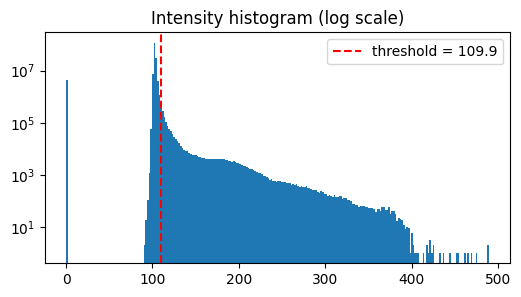

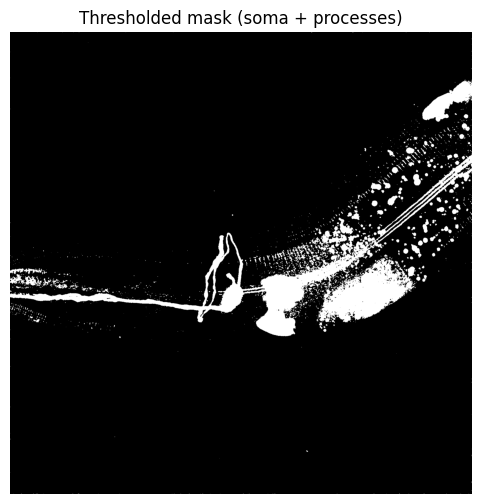

In [6]:
sigma_vox = [smoothing_sigma_um / vs for vs in voxel_size_zyx]
smoothed = gaussian(volume, sigma=sigma_vox, preserve_range=True)

threshold = threshold_triangle(smoothed)
mask = smoothed > threshold
print(f"Triangle threshold: {threshold:.2f} | foreground voxels: {mask.sum()} ({100 * mask.mean():.2f}%)")

plt.figure(figsize=(6, 3))
plt.hist(smoothed.ravel(), bins=256, log=True)
plt.axvline(threshold, color="r", linestyle="--", label=f"threshold = {threshold:.1f}")
plt.legend()
plt.title("Intensity histogram (log scale)")
plt.show()

mask_mip = np.max(mask, axis=0)
plt.figure(figsize=(6, 6))
plt.imshow(mask_mip, cmap="gray")
plt.title("Thresholded mask (soma + processes)")
plt.axis("off")
plt.show()

## 2. Strip processes with anisotropic morphological opening

The structuring element is a physically-round ellipsoid (round in um, squashed in voxel space to match the anisotropic Z sampling).

Opening structuring element shape (Z, Y, X): (3, 23, 23)
Foreground voxels after opening: 675674 (was 1298351)


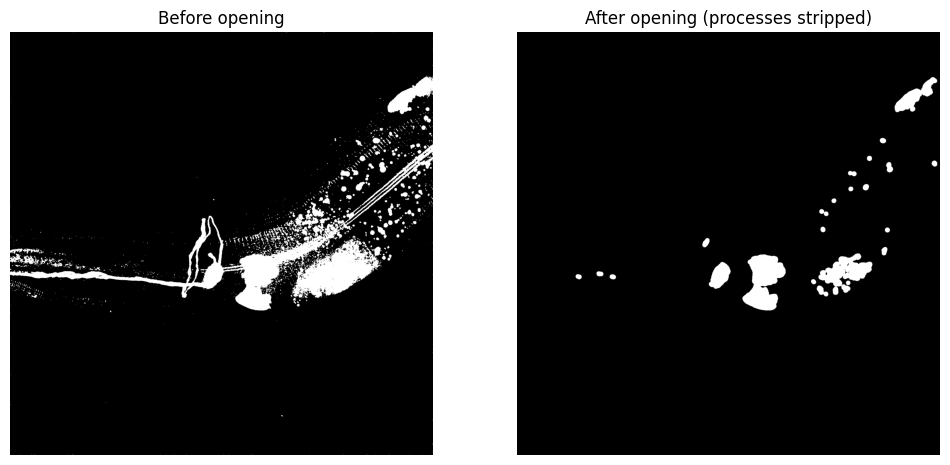

In [7]:
def ellipsoid_footprint(radius_um, voxel_size_zyx):
    """Boolean structuring element: a sphere of the given physical radius (um), expressed in voxels."""
    radii_vox = [max(1, int(round(radius_um / vs))) for vs in voxel_size_zyx]
    zz, yy, xx = np.mgrid[
        -radii_vox[0]:radii_vox[0] + 1,
        -radii_vox[1]:radii_vox[1] + 1,
        -radii_vox[2]:radii_vox[2] + 1,
    ]
    dist2 = (zz / radii_vox[0]) ** 2 + (yy / radii_vox[1]) ** 2 + (xx / radii_vox[2]) ** 2
    return dist2 <= 1


opening_footprint = ellipsoid_footprint(opening_radius_um, voxel_size_zyx)
print(f"Opening structuring element shape (Z, Y, X): {opening_footprint.shape}")

opened_mask = ndi.binary_opening(mask, structure=opening_footprint)
print(f"Foreground voxels after opening: {opened_mask.sum()} (was {mask.sum()})")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(mask_mip, cmap="gray")
axes[0].set_title("Before opening")
axes[0].axis("off")
axes[1].imshow(np.max(opened_mask, axis=0), cmap="gray")
axes[1].set_title("After opening (processes stripped)")
axes[1].axis("off")
plt.show()

## 3. Split touching somas via marker-controlled watershed

`distance_transform_edt` on the *full* frame needs a ~2 GB internal buffer regardless of how
sparse the actual signal is — slow/memory-heavy for no reason when neurons occupy a tiny
fraction of a 2048x2048x40 volume. Instead, label connected components after opening, crop to
each one's padded bounding box, and run the distance transform / watershed locally per
component. Same result, full resolution, a fraction of the memory and time.

In [8]:
peak_footprint = ellipsoid_footprint(min_peak_separation_um, voxel_size_zyx)

# pad each crop by at least the peak-separation radius so distance/peak values near the
# component's edge are computed with the same background context they'd see uncropped
pad_vox = [r + 2 for r in ((np.array(peak_footprint.shape) - 1) // 2)]

component_labels, num_components = ndi.label(opened_mask)
print(f"Found {num_components} connected component(s) after opening")

labels_ws = np.zeros_like(opened_mask, dtype=np.int32)
next_label = 1

for i, bbox in enumerate(ndi.find_objects(component_labels), start=1):
    if bbox is None:
        continue
    padded = tuple(
        slice(max(0, s.start - p), min(dim, s.stop + p))
        for s, p, dim in zip(bbox, pad_vox, opened_mask.shape)
    )
    local_mask = component_labels[padded] == i

    local_dist = ndi.distance_transform_edt(local_mask, sampling=voxel_size_zyx)
    local_peaks = peak_local_max(local_dist, footprint=peak_footprint, labels=local_mask, exclude_border=False)

    local_maxima = np.zeros_like(local_dist, dtype=bool)
    local_maxima[tuple(local_peaks.T)] = True
    local_markers, n_local = ndi.label(local_maxima)

    local_labels = watershed(-local_dist, local_markers, mask=local_mask)

    dest = labels_ws[padded]
    for local_id in range(1, n_local + 1):
        dest[local_labels == local_id] = next_label
        next_label += 1
    labels_ws[padded] = dest

num_markers = next_label - 1
print(f"Detected {num_markers} soma seed(s) total across {num_components} component(s)")

Found 30 connected component(s) after opening
Detected 77 soma seed(s) total across 30 component(s)


### Inspect candidates before filtering

Each numbered blob's ID matches the `label` column in step 4's unfiltered stats table — use this to visually find a specific object (e.g. the pharynx) and cross-reference its measured volume/solidity/intensity.

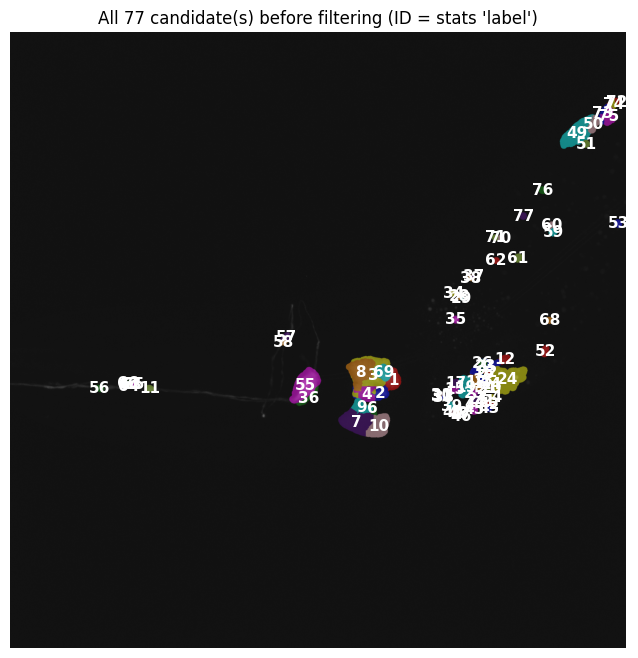

In [9]:
from skimage.measure import regionprops


def plot_labeled_candidates(labels, background_mip, title):
    """MIP of a label volume, colorized over the raw signal, with each object's ID at its centroid."""
    label_mip = np.max(labels, axis=0)
    overlay = label2rgb(label_mip, image=background_mip / background_mip.max(), bg_label=0, alpha=0.45)

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    for region in regionprops(label_mip):
        y, x = region.centroid
        plt.text(x, y, str(region.label), color="white", fontsize=11, fontweight="bold", ha="center", va="center")
    plt.title(title)
    plt.axis("off")
    plt.show()


plot_labeled_candidates(labels_ws, raw_mip, f"All {num_markers} candidate(s) before filtering (ID = stats 'label')")

## 4. Filter by size, shape, and intensity

Drops debris or any leftover non-soma blobs that survived opening. Prints the full unfiltered
candidate table first — use it to see actual measured volume/solidity/intensity for the real
neuron(s) vs. false positives, and adjust the thresholds in the Parameters cell accordingly.

In [24]:
props = regionprops_table(
    labels_ws,
    intensity_image=smoothed,
    spacing=voxel_size_zyx,
    properties=("label", "area", "solidity", "centroid", "mean_intensity"),
)
stats = pd.DataFrame(props).rename(columns={"area": "volume_um3"})

min_mean_intensity = threshold * min_mean_intensity_factor

print("All candidate objects (before filtering), sorted by volume:")
display(stats.sort_values("volume_um3", ascending=False).reset_index(drop=True))
print(f"min_mean_intensity cutoff = {min_mean_intensity:.2f} (threshold {threshold:.2f} x {min_mean_intensity_factor})")

volume_ok = (stats["volume_um3"] >= min_soma_volume_um3) & (stats["volume_um3"] <= max_soma_volume_um3)
solidity_ok = stats["solidity"] >= min_solidity
intensity_ok = stats["mean_intensity"] >= min_mean_intensity

print(
    f"Failed volume filter: {(~volume_ok).sum()} | "
    f"failed solidity filter: {(~solidity_ok).sum()} | "
    f"failed intensity filter: {(~intensity_ok).sum()}"
)

keep = stats[volume_ok & solidity_ok & intensity_ok].reset_index(drop=True)
print(f"Kept {len(keep)} / {len(stats)} candidate object(s)")

final_labels = np.zeros_like(labels_ws, dtype=np.uint16)
for new_id, old_label in enumerate(keep["label"], start=1):
    final_labels[labels_ws == old_label] = new_id
keep = keep.reset_index(drop=True)
keep.insert(0, "soma_id", range(1, len(keep) + 1))
keep = keep.drop(columns="label")

keep

c:\Users\josed\.conda\envs\tiffprocessing\Lib\site-packages\skimage\measure\_regionprops.py:468: UserWarning: Failed to get convex hull image. Returning empty image, see error message below:
QH6214 qhull input error: not enough points(3) to construct initial simplex (need 4)

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 333500480  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _maxoutside  0

  return convex_hull_image(self.image)
c:\Users\josed\.conda\envs\tiffprocessing\Lib\site-packages\skimage\measure\_regionprops.py:675: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex


All candidate objects (before filtering), sorted by volume:


,label,volume_um3,solidity,centroid-0,centroid-1,centroid-2,mean_intensity
0,3,1183.889188,0.672156,12.953941,114.436912,119.665953,144.305753
1,55,761.545215,0.826653,28.916522,117.693680,99.005759,151.219822
2,49,607.301772,0.766563,22.881503,33.311083,189.802617,120.057096
3,7,505.832135,0.604470,22.995363,130.035201,114.933620,117.344422
4,2,421.950569,0.635018,9.033263,120.500460,119.961981,154.412595
...,...,...,...,...,...,...,...
72,33,1.458476,0.625514,7.600000,121.967329,144.780829,111.929115
73,29,1.036286,0.627907,7.600000,88.878292,150.886792,166.386440
74,67,0.575714,0.631579,25.507500,117.492875,40.037525,121.776820
75,31,0.047976,1.000000,7.600000,121.424100,144.237600,111.837610


min_mean_intensity cutoff = 142.88 (threshold 109.91 x 1.3)
Failed volume filter: 65 | failed solidity filter: 69 | failed intensity filter: 64
Kept 2 / 77 candidate object(s)


,soma_id,volume_um3,solidity,centroid-0,centroid-1,centroid-2,mean_intensity
0,1,294.497029,0.829648,12.409058,119.153274,99.801837,157.677653
1,2,761.545215,0.826653,28.916522,117.693680,99.005759,151.219822


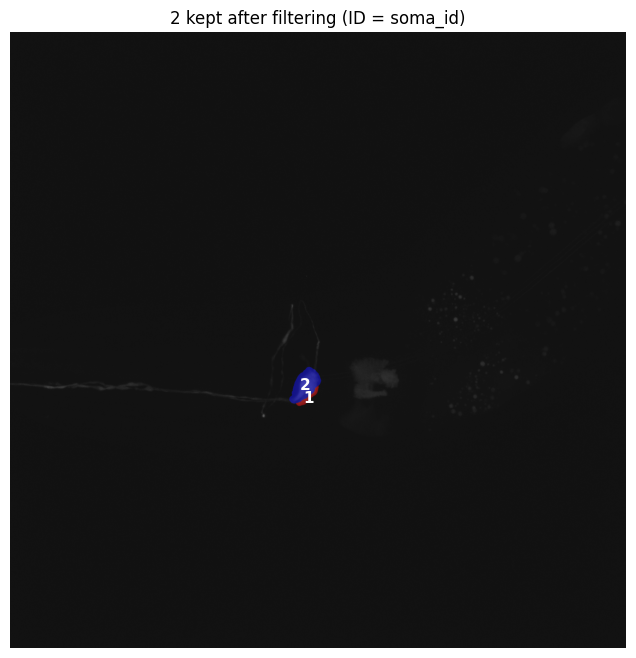

In [25]:
plot_labeled_candidates(final_labels, raw_mip, f"{len(keep)} kept after filtering (ID = soma_id)")

## 5. Visualize final segmentation

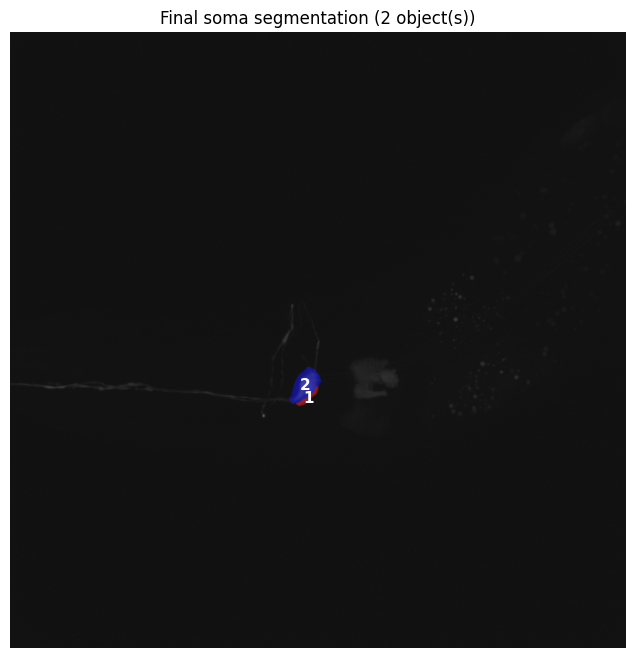

In [19]:
plot_labeled_candidates(final_labels, raw_mip, f"Final soma segmentation ({len(keep)} object(s))")

## 6. Save outputs

In [27]:
from pathlib import Path

ims_path_obj = Path(ims_path)
labels_out_path = ims_path_obj.with_name(ims_path_obj.stem + "_soma_labels.tif")
stats_out_path = ims_path_obj.with_name(ims_path_obj.stem + "_soma_stats.csv")

tifffile.imwrite(labels_out_path, final_labels)
keep.to_csv(stats_out_path, index=False)

print(f"Saved labeled volume -> {labels_out_path}")
print(f"Saved stats table -> {stats_out_path}")

Saved labeled volume -> G:\data\GFP\PS8292_soma_labels.tif
Saved stats table -> G:\data\GFP\PS8292_soma_stats.csv
